# ANN Classification — Breast Cancer Wisconsin

We train a Keras `Sequential` MLP with `Dropout` regularization to classify tumors as malignant or benign using the `load_breast_cancer` dataset (a standard scikit-learn built-in). This demonstrates a sigmoid output layer, binary cross-entropy loss, and dropout as discussed in `notes.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)

I0000 00:00:1787471969.836055   21963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787471969.836439   21963 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787471969.873165   21963 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0


I0000 00:00:1787471970.592264   21963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787471970.592530   21963 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load and split data

569 samples, 30 numeric features computed from digitized images of breast masses. Target: 0 = malignant, 1 = benign.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
print(X.shape, y.shape)
print('Class balance:', np.bincount(y), data.target_names)

(569, 30) (569,)
Class balance: [212 357] ['malignant' 'benign']


In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (364, 30) Val: (91, 30) Test: (114, 30)


## Build the MLP with Dropout

Two hidden `Dense` layers (ReLU, He init) each followed by `Dropout`, and a single sigmoid output neuron for binary classification.

In [4]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1787471970.863375   21963 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787471970.863708   22038 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787471970.886356   21963 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=16,
    callbacks=[early_stop], verbose=2)

Epoch 1/100


23/23 - 1s - 27ms/step - accuracy: 0.7088 - loss: 0.6023 - val_accuracy: 0.8901 - val_loss: 0.4339


Epoch 2/100


23/23 - 0s - 3ms/step - accuracy: 0.8187 - loss: 0.4257 - val_accuracy: 0.9121 - val_loss: 0.3123


Epoch 3/100


...

23/23 - 0s - 3ms/step - accuracy: 0.9863 - loss: 0.0500 - val_accuracy: 0.9670 - val_loss: 0.0865


Epoch 35/100


23/23 - 0s - 3ms/step - accuracy: 0.9863 - loss: 0.0390 - val_accuracy: 0.9670 - val_loss: 0.0858


Epoch 36/100


23/23 - 0s - 3ms/step - accuracy: 0.9863 - loss: 0.0483 - val_accuracy: 0.9670 - val_loss: 0.0869


## Training curves

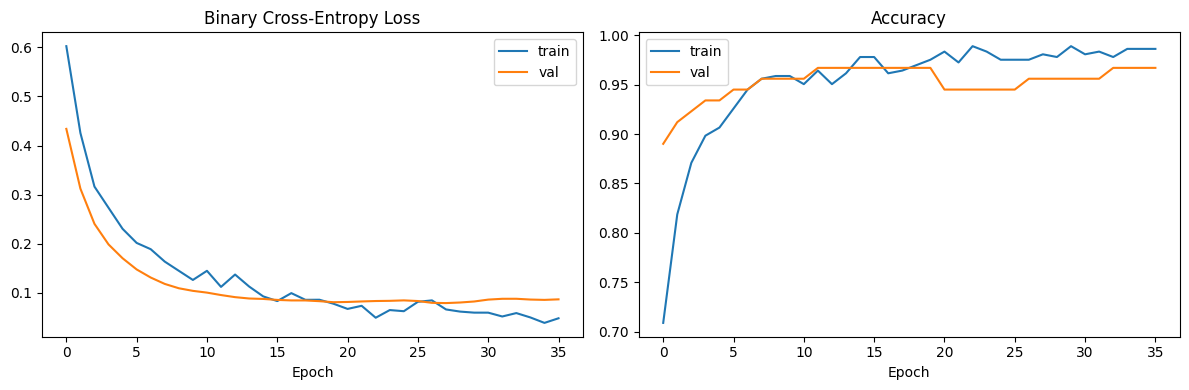

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Binary Cross-Entropy Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout()
plt.show()

## Evaluate on the test set

In [7]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')

Test accuracy: 0.9474
Test loss:     0.1128


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



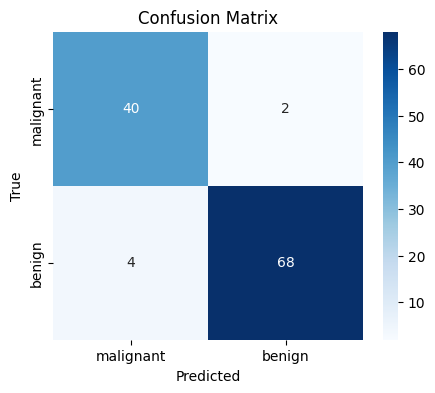

In [8]:
y_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

## Summary

Dropout regularization combined with a sigmoid output and binary cross-entropy loss produces a well-generalizing classifier on the Breast Cancer dataset, illustrating the regularization concepts from `notes.md`.